# CADE: reproducing the paper

This notebook reproduces the results in *CADE: Context-Aware Differentiable
Elastic Alignment for Time Series* (Holder, Qiu and Bagnall).

1. **CADE in practice.** The smooth between-gate, a soft alignment matrix, and a
   numerical check that the implemented gradient is correct.
2. **Averaging.** Table 1, from `results/averaging/`.
3. **Clustering.** Table 2 and the average-rank comparison (Figure 3), from
   `results/clustering/`.
4. **Classification.** The nearest-centroid comparison (Figure 4), from
   `results/classification/`.
5. **Dataset rebalancing (CADE-e-SMOTE).** Not yet in this repository (TODO).
6. **Re-running experiments.** How to regenerate the raw results, including the
   CricketX prototypes (Figure 2). Off by default because it needs the UCR archive
   and takes a long time.

Sections 2 to 4 only read the summary CSVs committed in `results/`, so they run in
seconds. Section 1 needs the PyTorch backend (`pip install -e ".[pytorch]"`).

In the result files, CADE-BA is still labelled with its pre-rename name
`soft-MBA`; the notebook relabels it for display.

In [1]:
import itertools
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import friedmanchisquare, rankdata, wilcoxon

# Run from the repository root so relative result paths resolve.
ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT)
RESULTS = ROOT / "results"

GAMMAS = ["1.0", "0.1", "0.01", "0.001"]
LABELS = {  # result-file names -> names used in the paper
    "soft-MBA": "CADE-BA",
    "soft-MBA2": "CADE-BA2",
    "soft-DBA": "Soft-DBA",
    "soft-DBA2": "Soft-DBA2",
}
pd.set_option("display.precision", 4)
print("results found:", sorted(p.name for p in RESULTS.iterdir()))

results found: ['averaging', 'classification', 'clustering']


## 1. CADE in practice

### The smooth between-gate

MSM charges a split or merge the fixed penalty $c$ when $x$ lies between $y$ and
$z$, and adds a deviation term otherwise. CADE replaces that hard test with

$$g(x,y,z)=\tfrac12\Bigl(1-\frac{u}{\sqrt{u^2+\varepsilon}}\Bigr),\qquad u=(x-y)(x-z).$$

The plot shows $g$ for $y=-1$, $z=1$. With a very small $\varepsilon$ the gate is
almost a step function. Larger values give a wider transition region. Because
$u$ has squared data scale, $\varepsilon$ has fourth-power data scale.

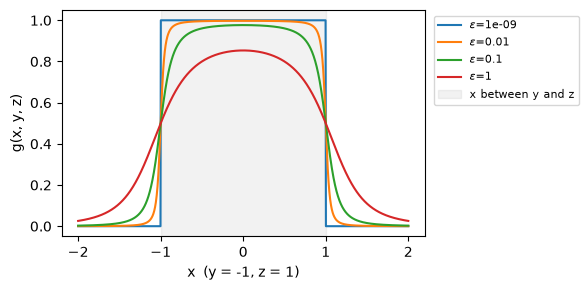

In [2]:
def between_gate(x, y, z, eps):
    u = (x - y) * (x - z)
    return 0.5 * (1.0 - u / np.sqrt(u * u + eps))


xs = np.linspace(-2, 2, 2001)
fig, ax = plt.subplots(figsize=(6, 3))
for eps in [1e-9, 1e-2, 1e-1, 1.0]:
    ax.plot(xs, between_gate(xs, -1.0, 1.0, eps), label=rf"$\varepsilon$={eps:g}")
ax.axvspan(-1, 1, color="grey", alpha=0.1, label="x between y and z")
ax.set_xlabel("x  (y = -1, z = 1)")
ax.set_ylabel("g(x, y, z)")
ax.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.01, 1))
fig.tight_layout()

### Loss, alignment matrix and gradient (PyTorch backend)

We align a sine wave with a time-shifted copy. The CADE alignment matrix $E$
concentrates around the warping path. As $\gamma$ grows, the mass spreads
over more alignments. As with Soft-DTW, the soft minimum can make the value
negative for large $\gamma$, because it sums over many paths.

In [3]:
try:
    import torch

    from cade.torch import CADELoss, cade_alignment_matrix, cade_grad_x

    HAVE_TORCH = True
except ImportError:
    HAVE_TORCH = False
    print('PyTorch backend not installed: pip install -e ".[pytorch]"')

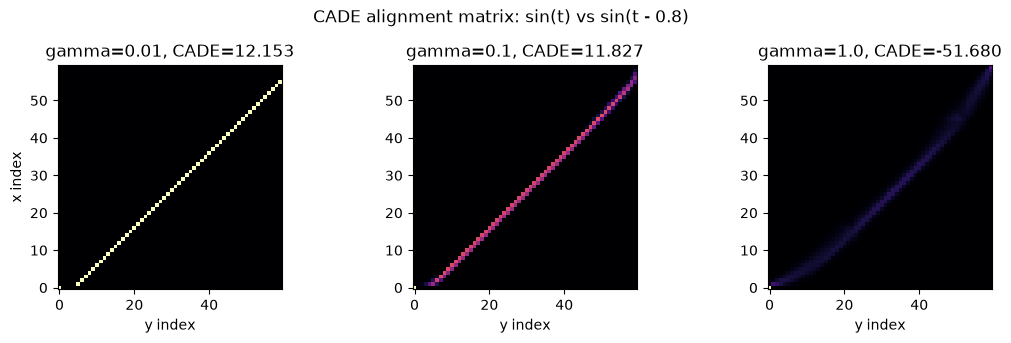

In [4]:
if HAVE_TORCH:
    t = np.linspace(0, 2 * np.pi, 60)
    x = torch.tensor(np.sin(t), dtype=torch.float64).reshape(1, 1, -1)
    y = torch.tensor(np.sin(t - 0.8), dtype=torch.float64).reshape(1, 1, -1)

    gammas = [0.01, 0.1, 1.0]
    fig, axes = plt.subplots(1, len(gammas), figsize=(11, 3.4))
    for ax, gamma in zip(axes, gammas):
        E, s = cade_alignment_matrix(x, y, c=1.0, gamma=gamma)
        ax.imshow(E[0].numpy(), origin="lower", cmap="magma")
        ax.set_title(f"gamma={gamma}, CADE={s.item():.3f}")
        ax.set_xlabel("y index")
    axes[0].set_ylabel("x index")
    fig.suptitle("CADE alignment matrix: sin(t) vs sin(t - 0.8)")
    fig.tight_layout()

The gradient from `cade_grad_x` is checked two ways on random pairs of series
with different lengths, in the spirit of the manuscript's gradient validation:

- against autograd through `CADELoss`;
- against central finite differences of the loss, with two step sizes $h$.

Finite differences need care near the gate's switching boundary. With the small
$\varepsilon$ used in the implementation, the gate changes very quickly there,
so a step of $h=10^{-6}$ can straddle the transition. In the table, that shows
up as a larger error on one pair (trial 2) that shrinks as $h$ gets smaller. It
is a limitation of the finite-difference check, not of the gradient.

In [5]:
def finite_difference(loss, x, y, h):
    fd = torch.zeros_like(x)
    for i in range(x.shape[-1]):
        xp, xm = x.clone(), x.clone()
        xp[0, 0, i] += h
        xm[0, 0, i] -= h
        fd[0, 0, i] = (loss(xp, y) - loss(xm, y)) / (2 * h)
    return fd


if HAVE_TORCH:
    rng = np.random.default_rng(123)
    rows = []
    for trial in range(10):
        m, n = rng.integers(5, 25, size=2)
        gamma = float(rng.choice([1.0, 0.5, 0.1, 0.05]))
        xt = torch.tensor(rng.normal(size=(1, 1, m)), dtype=torch.float64)
        yt = torch.tensor(rng.normal(size=(1, 1, n)), dtype=torch.float64)
        loss = CADELoss(c=1.0, gamma=gamma, reduction="sum")

        dx, _ = cade_grad_x(xt, yt, c=1.0, gamma=gamma)
        x_auto = xt.clone().requires_grad_(True)
        loss(x_auto, yt).backward()

        rows.append({
            "m": int(m), "n": int(n), "gamma": gamma,
            "max |grad|": dx.abs().max().item(),
            "vs autograd": (dx - x_auto.grad).abs().max().item(),
            "vs FD, h=1e-6": (dx - finite_difference(loss, xt, yt, 1e-6)).abs().max().item(),
            "vs FD, h=1e-8": (dx - finite_difference(loss, xt, yt, 1e-8)).abs().max().item(),
        })
    display(pd.DataFrame(rows).rename_axis("trial").style.format(
        {"max |grad|": "{:.2f}", "vs autograd": "{:.1e}", "vs FD, h=1e-6": "{:.1e}", "vs FD, h=1e-8": "{:.1e}"}
    ))

,m,n,gamma,max |grad|,vs autograd,"vs FD, h=1e-6","vs FD, h=1e-8"
trial,,,,,,,
0,5,18,0.100000,1.72,0.0e+00,3.5e-09,4.7e-07
1,6,12,1.000000,2.54,0.0e+00,1.6e-09,8.1e-08
2,23,8,0.100000,8.28,0.0e+00,2.2e-04,6.8e-07
3,11,14,1.000000,1.95,0.0e+00,5.2e-10,4.5e-08
4,16,23,0.050000,4.07,0.0e+00,4.3e-09,5.0e-07
5,10,14,1.000000,2.72,0.0e+00,2.5e-10,6.2e-08
6,8,12,0.100000,5.54,0.0e+00,5.7e-09,3.4e-07
7,21,13,1.000000,3.78,0.0e+00,1.6e-09,2.9e-07
8,8,22,1.000000,3.26,0.0e+00,1.8e-09,3.4e-07


## 2. Averaging (Table 1)

For each of 112 UCR datasets, 10 series are sampled from a random class and
averaged, with 10 repeats. Barycentres are always scored with the *hard*
distance of the reference geometry:

- **DTW geometry:** Soft-DTW barycentre vs DBA and SSG-DBA.
- **MSM geometry:** CADE-BA vs MBA and SSG-MBA.

Each cell is the percentage of datasets on which the soft method's mean loss is
lower than the baseline's.

In [6]:
from cade.evaluation import get_percentage_dataframe

table1 = pd.concat(
    {
        "Soft-DTW, DTW loss": get_percentage_dataframe("dtw"),
        "CADE, MSM loss": get_percentage_dataframe("msm"),
    },
    axis=1,
)
table1.index.name = "gamma"
table1.round(1)

Soft-DTW, DTW loss         CADE, MSM loss        
                     DBA SSG-DBA            MBA SSG-MBA
gamma                                                  
1.0                  2.8    14.7            7.3    26.6
0.1                 48.6    49.5           94.5    96.3
0.01                86.2    78.9           97.2   100.0
0.001               93.6    83.5           97.2   100.0

## 3. Clustering

### Table 2: soft averaging inside k-means

$k$-means (with $k$ equal to the number of classes) is run with CADE-BA and
Soft-DBA centroids, with the hard distance used for assignment. Each entry is the
percentage of datasets on which the soft variant reaches lower inertia than its
hard counterpart (MBA and DBA respectively). Only datasets where both runs
finished are counted, so the number of datasets varies by column. The paper
omits the $\gamma = 1$ row.

In [7]:
inertia = pd.read_csv(RESULTS / "clustering" / "inertia_values.csv")


def better_than_hard(soft_prefix, base):
    rows = {}
    for g in GAMMAS:
        col = f"{soft_prefix}-hard-dist-gamma-{g}"
        both = inertia[[base, col]].dropna()
        rows[g] = {"better (%)": round(100 * (both[col] < both[base]).mean(), 1),
                   "datasets": len(both)}
    return pd.DataFrame(rows).T.astype({"datasets": int})


table2 = pd.concat(
    {"CADE-BA vs MBA": better_than_hard("soft-MBA", "MBA"),
     "Soft-DBA vs DBA": better_than_hard("soft-DBA", "DBA")},
    axis=1,
)
table2.index.name = "gamma"
table2

CADE-BA vs MBA          Soft-DBA vs DBA         
          better (%) datasets      better (%) datasets
gamma                                                 
1.0              8.3       72             1.9      104
0.1             87.2       94            10.6      104
0.01            84.8       99            55.4      101
0.001           83.5       97            84.8      105

### Figure 3: comparison with $k$-AVG and $k$-Shape

The paper's critical difference diagrams come from
`aeon.visualisation.plot_critical_difference` with its defaults: $\alpha=0.1$,
pairwise Wilcoxon signed-rank tests, and `correction="holm"`. The helper below
reimplements that procedure, so the notebook doesn't depend on aeon's plotting
module. aeon's procedure works like this:

- It runs a **Friedman test**. If that is not significant, all methods form a
  single clique.
- It runs **one-sided** Wilcoxon tests between each pair of methods, ordered by
  average rank.
- It compares every p-value with the fixed threshold $\alpha/(k-1)$.
- It builds cliques from the ranked list. Once method $i$ is significantly
  different from method $j$, it is also treated as different from every method
  ranked below $j$.

That last rule means a clique diagram can separate two methods whose *direct*
pairwise test is not significant. The table after each diagram therefore also
lists the direct pairwise p-values.

In [8]:
def cd_analysis(scores, alpha=0.1):
    # Reimplements aeon.visualisation.plot_critical_difference (wilcoxon, holm).
    labels = list(scores.columns)
    k = len(labels)
    ranks = np.vstack([rankdata(-row) for row in scores.to_numpy()])
    avg_ranks = pd.Series(ranks.mean(axis=0), index=labels).sort_values()
    order = list(avg_ranks.index)
    friedman_p = friedmanchisquare(*[scores[c] for c in labels]).pvalue
    threshold = alpha / (k - 1)

    p = np.ones((k, k))
    for i, j in itertools.combinations(range(k), 2):
        a, b = scores[order[i]], scores[order[j]]
        p[i, j] = wilcoxon(a, b, zero_method="wilcox", alternative="greater").pvalue

    if friedman_p >= alpha:
        cliques = [order]
    else:
        same = p > threshold
        for i in range(k):  # propagate: different from j => different from all below j
            for j in range(i + 1, k):
                if not same[i, j]:
                    same[i, j + 1:] = False
                    break
        cliques = []
        for i in range(k):
            members = [order[i]] + [order[j] for j in range(i + 1, k) if same[i, j]]
            if len(members) > 1 and not any(set(members) <= set(c) for c in cliques):
                cliques.append(members)

    pairs = pd.DataFrame(
        [
            {
                "higher rank": order[i],
                "lower rank": order[j],
                "mean score diff": scores[order[i]].mean() - scores[order[j]].mean(),
                "one-sided p": p[i, j],
                f"direct test p < {threshold:.3f}": p[i, j] < threshold,
                "separated in diagram": not any({order[i], order[j]} <= set(c) for c in cliques),
            }
            for i, j in itertools.combinations(range(k), 2)
        ]
    )
    return avg_ranks, friedman_p, cliques, pairs


def plot_ranks(avg_ranks, cliques, title, ax):
    # Critical-difference style: rank axis (best on the right), labels fanned out
    # to the sides, cliques as thick bars joining methods with no significant difference.
    k = len(avg_ranks)
    left_x, right_x = k + 0.6, 0.4
    ax.plot([k, 1], [0, 0], color="black", lw=1)
    for r in range(1, k + 1):
        ax.plot([r, r], [0, 0.08], color="black", lw=1)
        ax.text(r, 0.14, str(r), ha="center", va="bottom", fontsize=8)
    clique_y = [-0.12 - 0.12 * c for c in range(len(cliques))]
    label_top = min(clique_y, default=0) - 0.2
    items = list(avg_ranks.items())  # best first
    right = items[: (k + 1) // 2]
    left = items[(k + 1) // 2:][::-1]  # worst first
    for side, group, x_text, ha in [("r", right, right_x, "right"), ("l", left, left_x, "left")]:
        for level, (name, rank) in enumerate(group):
            y = label_top - 0.28 * level
            colour = "C3" if name.startswith("CADE") else "black"
            ax.plot([rank, rank, x_text], [0, y, y], color=colour, lw=0.8)
            ax.text(x_text + (-0.05 if ha == "right" else 0.05), y, f"{name} ({rank:.3f})",
                    ha="left" if ha == "right" else "right", va="center", fontsize=8,
                    color=colour)
    for y, members in zip(clique_y, cliques):
        lo, hi = avg_ranks[members].min(), avg_ranks[members].max()
        ax.plot([lo - 0.04, hi + 0.04], [y, y], color="black", lw=3, solid_capstyle="butt")
    ax.set_xlim(left_x + 1.4, right_x - 1.4)
    ax.set_ylim(label_top - 0.28 * max(len(left), len(right)), 0.45)
    ax.set_title(title, fontsize=10)
    ax.axis("off")


def compare(folder, files, alpha=0.1):
    fig, axes = plt.subplots(1, len(files), figsize=(6 * len(files), 2.8))
    tables = {}
    for ax, (fname, title) in zip(np.atleast_1d(axes), files.items()):
        scores = pd.read_csv(RESULTS / folder / fname, index_col=0).rename(columns=LABELS)
        avg_ranks, friedman_p, cliques, pairs = cd_analysis(scores, alpha)
        plot_ranks(avg_ranks, cliques, f"{title} ({len(scores)} datasets)", ax)
        print(f"{title}: Friedman p = {friedman_p:.2e}; mean scores:",
              scores.mean().round(4).to_dict())
        tables[title] = pairs
    fig.tight_layout()
    plt.show()
    return tables

Clustering accuracy: Friedman p = 6.42e-04; mean scores: {'k-AVG': 0.5344, 'k-Shape': 0.5662, 'Soft-DBA': 0.5588, 'CADE-BA': 0.5817}
Adjusted Rand index: Friedman p = 8.62e-04; mean scores: {'k-AVG': 0.2097, 'k-Shape': 0.2506, 'Soft-DBA': 0.2422, 'CADE-BA': 0.2747}


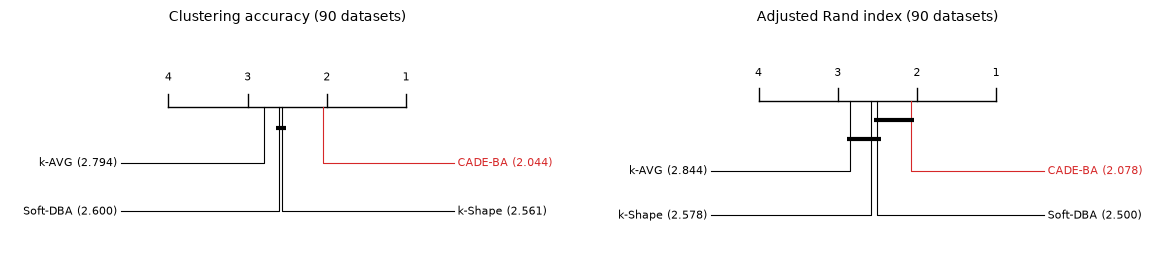

,higher rank,lower rank,mean score diff,one-sided p,direct test p < 0.033,separated in diagram
0,CADE-BA,k-Shape,0.0155,1.8960e-03,True,True
1,CADE-BA,Soft-DBA,0.0229,5.2323e-02,False,True
2,CADE-BA,k-AVG,0.0473,1.2004e-05,True,True
3,k-Shape,Soft-DBA,0.0074,4.1225e-01,False,False
4,k-Shape,k-AVG,0.0318,1.5975e-02,True,True
5,Soft-DBA,k-AVG,0.0244,2.0731e-02,True,True


In [9]:
clustering = compare(
    "clustering",
    {"clacc_mean.csv": "Clustering accuracy", "ari_mean.csv": "Adjusted Rand index"},
)
clustering["Clustering accuracy"]

In [10]:
clustering["Adjusted Rand index"]

,higher rank,lower rank,mean score diff,one-sided p,direct test p < 0.033,separated in diagram
0,CADE-BA,Soft-DBA,0.0325,8.5963e-02,False,False
1,CADE-BA,k-Shape,0.0240,1.6025e-03,True,True
2,CADE-BA,k-AVG,0.0649,2.4990e-06,True,True
3,Soft-DBA,k-Shape,-0.0084,3.3261e-01,False,False
4,Soft-DBA,k-AVG,0.0325,3.6129e-02,False,False
5,k-Shape,k-AVG,0.0409,1.3951e-02,True,False


CADE-BA has the best average rank and mean score on both measures, and is
significantly better than $k$-AVG and $k$-Shape in direct tests. Against Soft-DBA
on clustering accuracy, the diagram separates the two methods only through
clique propagation. The direct one-sided test gives $p \approx 0.05$, which is
above the $\alpha/(k-1)$ threshold. AMI and NMI results are also in
`results/clustering/`.

## 4. Classification (Figure 4)

The nearest-centroid classifier uses one barycentre per class, fitted on the
training data:

- **Soft-DBA / CADE-BA:** the soft function forms the centroids *and* finds the
  nearest centroid.
- **Soft-DBA2 / CADE-BA2:** the soft function forms the centroids; the hard
  distance (DTW or MSM) finds the nearest centroid.

Accuracy: Friedman p = 9.24e-05; mean scores: {'Soft-DBA': 0.6454, 'Soft-DBA2': 0.6437, 'CADE-BA': 0.657, 'CADE-BA2': 0.6608}
Balanced accuracy: Friedman p = 1.15e-02; mean scores: {'Soft-DBA': 0.6407, 'Soft-DBA2': 0.6389, 'CADE-BA': 0.6525, 'CADE-BA2': 0.6554}


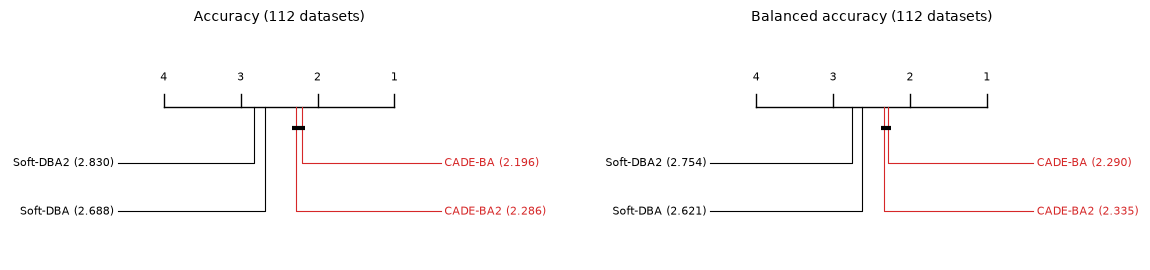

,higher rank,lower rank,mean score diff,one-sided p,direct test p < 0.033,separated in diagram
0,CADE-BA,CADE-BA2,-0.0038,0.6352,False,False
1,CADE-BA,Soft-DBA,0.0116,0.0168,True,True
2,CADE-BA,Soft-DBA2,0.0132,0.0105,True,True
3,CADE-BA2,Soft-DBA,0.0154,0.0091,True,True
4,CADE-BA2,Soft-DBA2,0.0170,0.0066,True,True
5,Soft-DBA,Soft-DBA2,0.0016,0.0024,True,True


In [11]:
classification = compare(
    "classification",
    {"accuracy_mean.csv": "Accuracy", "balacc_mean.csv": "Balanced accuracy"},
)
classification["Accuracy"]

In [12]:
classification["Balanced accuracy"]

,higher rank,lower rank,mean score diff,one-sided p,direct test p < 0.033,separated in diagram
0,CADE-BA,CADE-BA2,-0.0029,0.5621,False,False
1,CADE-BA,Soft-DBA,0.0118,0.0108,True,True
2,CADE-BA,Soft-DBA2,0.0136,0.0067,True,True
3,CADE-BA2,Soft-DBA,0.0147,0.0098,True,True
4,CADE-BA2,Soft-DBA2,0.0165,0.0074,True,True
5,Soft-DBA,Soft-DBA2,0.0018,0.0016,True,True


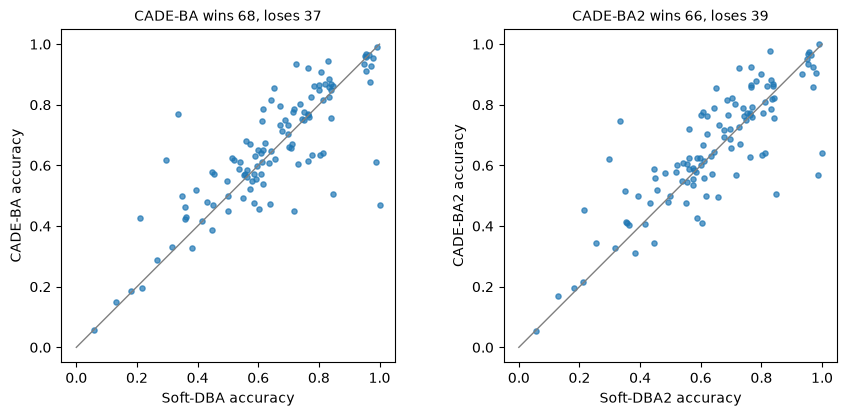

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4.2))
acc = pd.read_csv(RESULTS / "classification" / "accuracy_mean.csv", index_col=0).rename(columns=LABELS)
for ax, (cade, soft) in zip(axes, [("CADE-BA", "Soft-DBA"), ("CADE-BA2", "Soft-DBA2")]):
    wins = (acc[cade] > acc[soft]).sum()
    losses = (acc[cade] < acc[soft]).sum()
    ax.scatter(acc[soft], acc[cade], s=14, alpha=0.7)
    ax.plot([0, 1], [0, 1], color="grey", lw=1)
    ax.set_xlabel(f"{soft} accuracy")
    ax.set_ylabel(f"{cade} accuracy")
    ax.set_title(f"{cade} wins {wins}, loses {losses}", fontsize=10)
    ax.set_aspect("equal")
fig.tight_layout()

## 5. Dataset rebalancing (CADE-e-SMOTE)

> **TODO.** The CADE-e-SMOTE code, the 60 imbalanced UCR problems, the HIVE-COTE
> 2.0 results (Table 3, Figures 5 and 6) and the $\gamma$ sensitivity analysis
> are not yet in this repository. This section will be filled in once they are
> added.

## 6. Re-running the experiments

The summary CSVs above were produced by the scripts in `cade/experiments/`.
Re-running them requires:

- the UCR archive locally, with `DATASET_PATH` and `RESULT_PATH` set in `.env`
  (see `.env.example`);
- the aeon development branch installed by `pip install -e .`, which provides
  the Numba soft distances and barycentre methods.

Full runs over 112 datasets are intended for a compute cluster. The cell below
regenerates the CricketX prototypes (Figure 2) and is the quickest end-to-end
check. Set `RUN_EXPERIMENTS = True` to run it.

In [14]:
RUN_EXPERIMENTS = False

if RUN_EXPERIMENTS:
    from aeon.clustering.averaging import elastic_barycenter_average

    from cade.experiments._utils import (
        get_averaging_params,
        load_and_validate_env,
        load_dataset_from_file,
    )

    env = load_and_validate_env()
    X, y, _, _ = load_dataset_from_file(
        "CricketX", Path(env["DATASET_PATH"]), normalize=True, combine_test_train=False
    )
    X_class = X[y == "12"][:, 0, :]

    configs = {
        "CADE (γ=0.001)": ("soft", {"gamma": 0.001, "distance": "soft_msm"}),
        "Soft-DTW (γ=0.001)": ("soft", {"gamma": 0.001, "distance": "soft_dtw"}),
        "MBA": ("petitjean", {"distance": "msm"}),
        "SSG-MBA": ("subgradient", {"distance": "msm"}),
    }
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
    for ax, (label, (method, params)) in zip(axes.ravel(), configs.items()):
        bary = elastic_barycenter_average(
            X_class, method=method, random_state=1,
            **{**get_averaging_params(method), **params},
        )
        ax.plot(X_class.T, color="black", lw=0.5, alpha=0.3)
        ax.plot(np.asarray(bary).reshape(-1), color="C3", lw=2.5)
        ax.set_title(label)
    fig.suptitle("Class 12 averages on CricketX")
    fig.tight_layout()
else:
    print("Skipped. Set RUN_EXPERIMENTS = True to regenerate Figure 2.")

Skipped. Set RUN_EXPERIMENTS = True to regenerate Figure 2.


Command-line entry points for the full experiments (see the README for details):

```bash
python -m cade.experiments._averaging_experiment <distances_csv> <averaging_method> <repeats> <combine_test_train>
python -m cade.experiments._clustering_experiment <dataset> <model> <combine_test_train> <dataset_path> <results_path> [gamma]
python -m cade.experiments._classification_experiment <dataset> <model> <dataset_path> <results_path> [gamma]
```